In [1]:
# importing libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


In [4]:
# Downloading stock data
stock_symbol = "AAPL"
data = yf.download(stock_symbol, start="2015-01-01")
print(data.head())
print(data.index[-1])

[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2015-01-02  24.214897  24.682230  23.776357  24.671155  212818400
2015-01-05  23.532726  24.064289  23.346680  23.984555  257142000
2015-01-06  23.534937  23.794073  23.173916  23.596952  263188400
2015-01-07  23.864948  23.964616  23.632389  23.743131  160423600
2015-01-08  24.781893  24.839479  24.075357  24.192745  237458000
2026-03-02 00:00:00


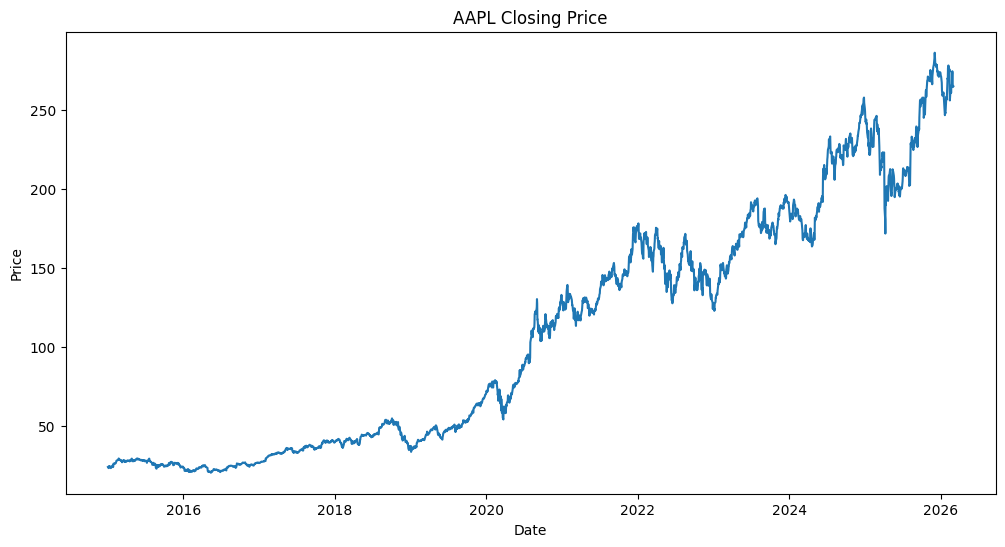

In [5]:
# Visualizing closing price
plt.figure(figsize=(12,6))
plt.plot(data['Close'])
plt.title(f"{stock_symbol} Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [6]:
# close column
close_data = data[['Close']]
close_data.head()

Price,Close
Ticker,AAPL
Date,
2015-01-02,24.214897
2015-01-05,23.532726
2015-01-06,23.534937
2015-01-07,23.864948
2015-01-08,24.781893


In [7]:
# Normalize data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(close_data)

scaled_data[:5]

array([[0.013681  ],
       [0.01111005],
       [0.01111838],
       [0.01236212],
       [0.01581789]])

In [8]:
# create sequences ( 60 days )
x = []
y = []

for i in range(60,len(scaled_data)):
    x.append(scaled_data[i-60:i,0])
    y.append(scaled_data[i,0])

x = np.array(x)
y = np.array(y)

x.shape, y.shape

((2746, 60), (2746,))

In [10]:
# Reshape for LSTM
x = x.reshape(x.shape[0],x.shape[1],1) #(samples, time_steps, features)

x.shape

(2746, 60, 1)

In [11]:
# Split train and test
split = int(0.8*len(x)) # 80% Train and 20% Test

x_train,x_test = x[:split],x[split:]
y_train,y_test = y[:split],y[split:]

x_train.shape, x_test.shape

((2196, 60, 1), (550, 60, 1))

In [12]:
# Build LSTM Model
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(60,1))) # 60 days(timestamps) X 1 feature(closing price)
model.add(Dropout(0.2)) 
# dropout removes 20% neurons randomly during training to prevent overfitting

model.add(LSTM(50))
model.add(Dropout(0.2))

model.add(Dense(1)) # predicting one output(next day price)

model.compile(optimizer='adam',loss='mean_squared_error')

model.summary()

c:\Projects\New folder\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Train model
history = model.fit(
    x_train,y_train,
    epochs=20, #One epoch = The model sees the entire training dataset once.
    batch_size=32, # 1 batch = 32 samples
    validation_data=(x_test,y_test)
)

Epoch 1/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - loss: 0.0079 - val_loss: 0.0020
Epoch 2/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 0.0014 - val_loss: 0.0027
Epoch 3/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0011 - val_loss: 0.0012
Epoch 4/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0010 - val_loss: 0.0015
Epoch 5/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.0012 - val_loss: 0.0014
Epoch 6/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 9.6908e-04 - val_loss: 0.0025
Epoch 7/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 9.1963e-04 - val_loss: 0.0012
Epoch 8/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 9.8936e-04 - val_loss: 0.0011
Epoch 9/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 9.1272e-04 - val_loss: 0.0027
Epoch 10/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 7.6996e-04 - val_loss: 0.0012
Epoch 11/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 7.9223e-04 - val_loss: 0.0026
Epoch 12/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 

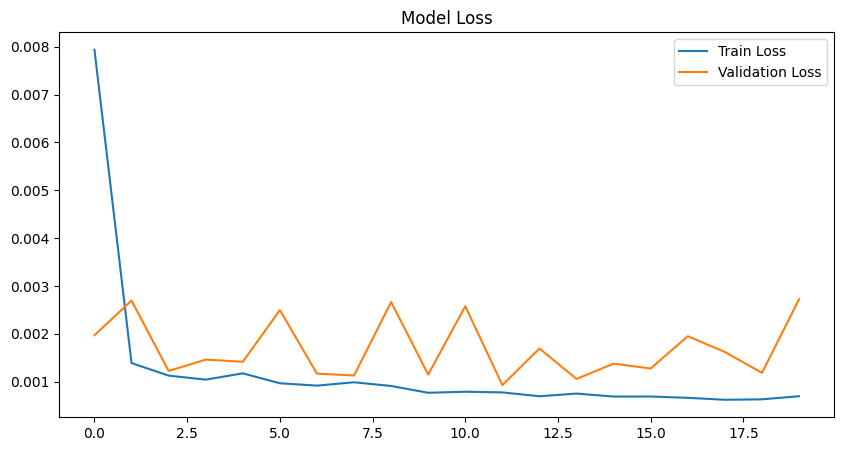

In [14]:
# Plot training Loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'],label='Train Loss') # Error on training data
plt.plot(history.history['val_loss'],label='Validation Loss') # Error on validation data
plt.legend()
plt.title("Model Loss")
plt.show()

In [15]:
# Make predictions

predictions = model.predict(x_test) # predicting the next day price, will be a normalized output

predictions = scaler.inverse_transform(predictions) # to get original price from normalized prize
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1)) # reshape() - because scaler expects 2D array

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


In [16]:
rmse = np.sqrt(mean_squared_error(y_test_actual,predictions)) # root mean squared error
mae = mean_absolute_error(y_test_actual,predictions)

print("RMSE : ",rmse)
print("MAE : ",mae)

RMSE :  13.848428503770645
MAE :  11.912899058948863


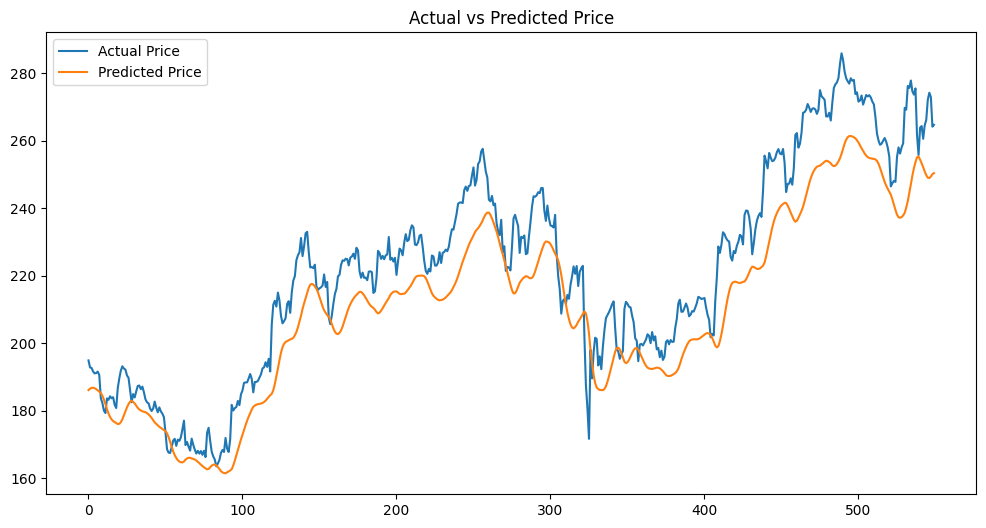

In [17]:
# plotting actual vs predicted
plt.figure(figsize=(12,6))
plt.plot(y_test_actual,label='Actual Price')
plt.plot(predictions,label='Predicted Price')
plt.legend()
plt.title("Actual vs Predicted Price")
plt.show()

In [18]:
last_60_days = scaled_data[-60:]
last_60_days = last_60_days.reshape(1,60,1)

next_day = model.predict(last_60_days)
next_day_price = scaler.inverse_transform(next_day)

print("Tomorrow's Predicted Price : ",next_day_price[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Tomorrow's Predicted Price :  250.48361


In [19]:
# Save Model
model.save("lstm_model.h5")